# Visualização e Debug — Notebook 4/4

## Aula: Aspectos Técnicos de CNNs em PyTorch

### Objetivo

Apresentar o **ferramental técnico** que diferencia um usuário casual do PyTorch de um engenheiro de ML maduro: hooks múltiplos, **Grad-CAM**, **mixed precision**, persistência correta, **TorchScript**, **reprodutibilidade** garantida e **benchmarking** do DataLoader.

### O que vamos cobrir

1. Inspeção completa do `state_dict` (chaves, tamanhos, contagem de parâmetros).
2. **Hooks múltiplos**: capturar ativação em várias camadas de uma vez.
3. Visualização dos filtros aprendidos (`conv1`).
4. **Grad-CAM**: heatmap de explicabilidade — mostra onde a CNN "olha" para tomar a decisão.
5. **Mixed precision** com `torch.cuda.amp.autocast` + `GradScaler`.
6. Persistência correta: salvar/carregar `state_dict` e verificar igualdade.
7. Export para **TorchScript** (`torch.jit.trace`).
8. **Reprodutibilidade** total com seed em 4 lugares.
9. Benchmark de **num_workers** no DataLoader.
10. Checklist final de boas práticas.

### Pré-requisitos
- Notebooks 1, 2 e 3.
- Familiaridade com `nn.Module` e `state_dict`.

## 1. Importações

In [1]:
import os
import time
import random
import requests
from io import BytesIO

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision import models
from torchvision.models import ResNet18_Weights

def selecionar_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")

device = selecionar_device()
print(f"Usando device: {device}")
print(f"PyTorch: {torch.__version__}")

Usando device: mps
PyTorch: 2.7.1


## 2. Modelo de referência: ResNet18 pré-treinada

Vamos usar a ResNet18 pré-treinada no ImageNet ao longo do notebook. Carregamos em `eval()` para fixar Dropout/BN.

In [2]:
weights = ResNet18_Weights.DEFAULT
modelo = models.resnet18(weights=weights).to(device).eval()
print("ResNet18 pronta.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/rooneycoelho/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  1%|          | 256k/44.7M [00:00<00:32, 1.43MB/s]

  1%|          | 512k/44.7M [00:00<00:36, 1.28MB/s]

  2%|▏         | 768k/44.7M [00:00<00:29, 1.56MB/s]

...

 99%|█████████▉| 44.1M/44.7M [00:35<00:00, 965kB/s]

 99%|█████████▉| 44.2M/44.7M [00:35<00:00, 1.02MB/s]

100%|█████████▉| 44.5M/44.7M [00:35<00:00, 1.12MB/s]

100%|██████████| 44.7M/44.7M [00:36<00:00, 1.30MB/s]

ResNet18 pronta.


## 3. Inspecionando o `state_dict`

O **state_dict** é um `OrderedDict` que mapeia nomes de tensores → seus valores. É **o** objeto canônico para serializar um modelo.

Diferença útil:
- `parameters()`: só pesos aprendíveis.
- `state_dict()`: pesos aprendíveis **+ buffers** (ex: `running_mean`/`running_var` da BN). Por isso é o correto para salvar.

In [3]:
sd = modelo.state_dict()
print(f"Total de chaves no state_dict: {len(sd)}\n")
print("Primeiras 10 chaves e seus shapes:")
for k in list(sd.keys())[:10]:
    print(f"  {k:<35} {tuple(sd[k].shape)}")
print("...")
print("Últimas 5 chaves:")
for k in list(sd.keys())[-5:]:
    print(f"  {k:<35} {tuple(sd[k].shape)}")

Total de chaves no state_dict: 122

Primeiras 10 chaves e seus shapes:
  conv1.weight                        (64, 3, 7, 7)
  bn1.weight                          (64,)
  bn1.bias                            (64,)
  bn1.running_mean                    (64,)
  bn1.running_var                     (64,)
  bn1.num_batches_tracked             ()
  layer1.0.conv1.weight               (64, 64, 3, 3)
  layer1.0.bn1.weight                 (64,)
  layer1.0.bn1.bias                   (64,)
  layer1.0.bn1.running_mean           (64,)
...
Últimas 5 chaves:
  layer4.1.bn2.running_mean           (512,)
  layer4.1.bn2.running_var            (512,)
  layer4.1.bn2.num_batches_tracked    ()
  fc.weight                           (1000, 512)
  fc.bias                             (1000,)


In [4]:
# Contando parâmetros
total = sum(p.numel() for p in modelo.parameters())
treinaveis = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
buffers = sum(b.numel() for b in modelo.buffers())

print(f"Parâmetros totais:     {total:>12,}")
print(f"Parâmetros treináveis: {treinaveis:>12,}")
print(f"Buffers (não-treináveis, ex: BN stats): {buffers:>12,}")

Parâmetros totais:       11,689,512
Parâmetros treináveis:   11,689,512
Buffers (não-treináveis, ex: BN stats):        9,620


## 4. Preparando uma imagem de teste

Usamos uma imagem pública estável (mesma do notebook 3) para os experimentos a seguir.

img_tensor: torch.Size([1, 3, 224, 224])


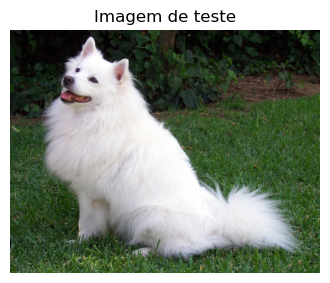

In [5]:
URL_IMG = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
resp = requests.get(URL_IMG, timeout=10)
img_pil = Image.open(BytesIO(resp.content)).convert("RGB")

preproc = weights.transforms()
img_tensor = preproc(img_pil).unsqueeze(0).to(device)
print(f"img_tensor: {img_tensor.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(img_pil); plt.axis('off'); plt.title('Imagem de teste'); plt.show()

## 5. Hooks em múltiplas camadas

Vamos registrar **forward hooks** em 4 camadas diferentes para ver como a ativação evolui ao longo da profundidade.

Conceito: quanto mais fundo, mais **abstrato/semântico** o feature map fica (e mais canais, com resolução menor).

In [6]:
ativacoes = {}

def make_hook(nome):
    def hook(modulo, entrada, saida):
        ativacoes[nome] = saida.detach()
    return hook

# Registra hooks em 4 camadas; guardamos handles para remover depois
handles = []
handles.append(modelo.conv1.register_forward_hook(make_hook('conv1')))
handles.append(modelo.layer1[0].register_forward_hook(make_hook('layer1[0]')))
handles.append(modelo.layer2[0].register_forward_hook(make_hook('layer2[0]')))
handles.append(modelo.layer3[0].register_forward_hook(make_hook('layer3[0]')))

with torch.no_grad():
    _ = modelo(img_tensor)

# Limpa hooks (sempre!)
for h in handles:
    h.remove()

for nome, t in ativacoes.items():
    print(f"  {nome:<14} shape={tuple(t.shape)}")

  conv1          shape=(1, 64, 112, 112)
  layer1[0]      shape=(1, 64, 56, 56)
  layer2[0]      shape=(1, 128, 28, 28)
  layer3[0]      shape=(1, 256, 14, 14)


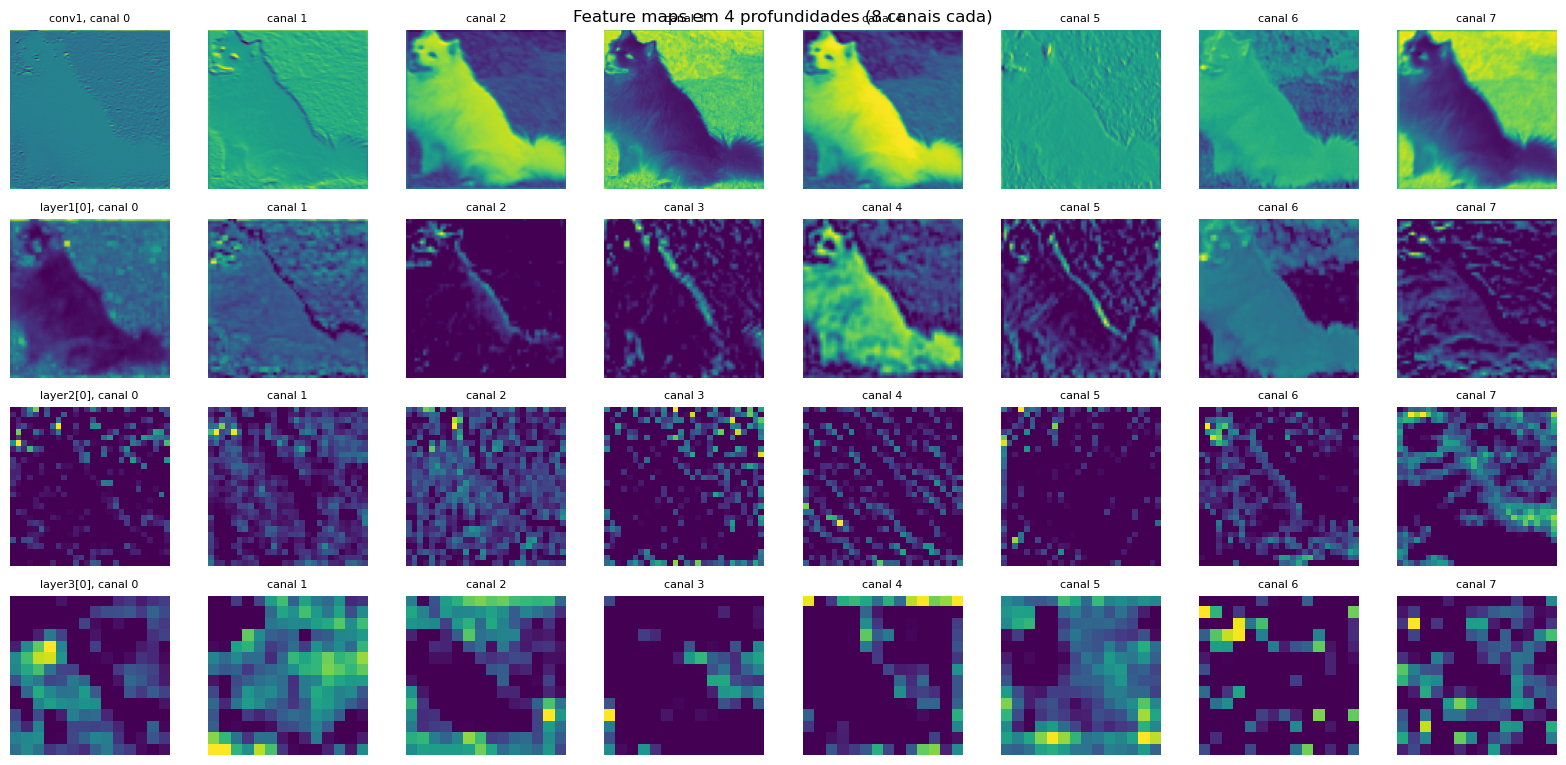

In [7]:
# Visualiza 8 ativações de cada uma das 4 camadas (4 linhas x 8 colunas)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for linha, (nome, fmaps) in enumerate(ativacoes.items()):
    for col in range(8):
        ax = axes[linha, col]
        ax.imshow(fmaps[0, col].cpu().numpy(), cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(nome, fontsize=10)
            ax.set_title(f'{nome}, canal {col}', fontsize=8)
        else:
            ax.set_title(f'canal {col}', fontsize=8)
plt.suptitle('Feature maps em 4 profundidades (8 canais cada)', y=0.95)
plt.tight_layout(); plt.show()

## 6. Visualizando os filtros aprendidos de `conv1`

Lembrete: aqui são **os pesos**, não as ativações. Cada filtro 7x7 RGB é visualizável como uma imagenzinha colorida.

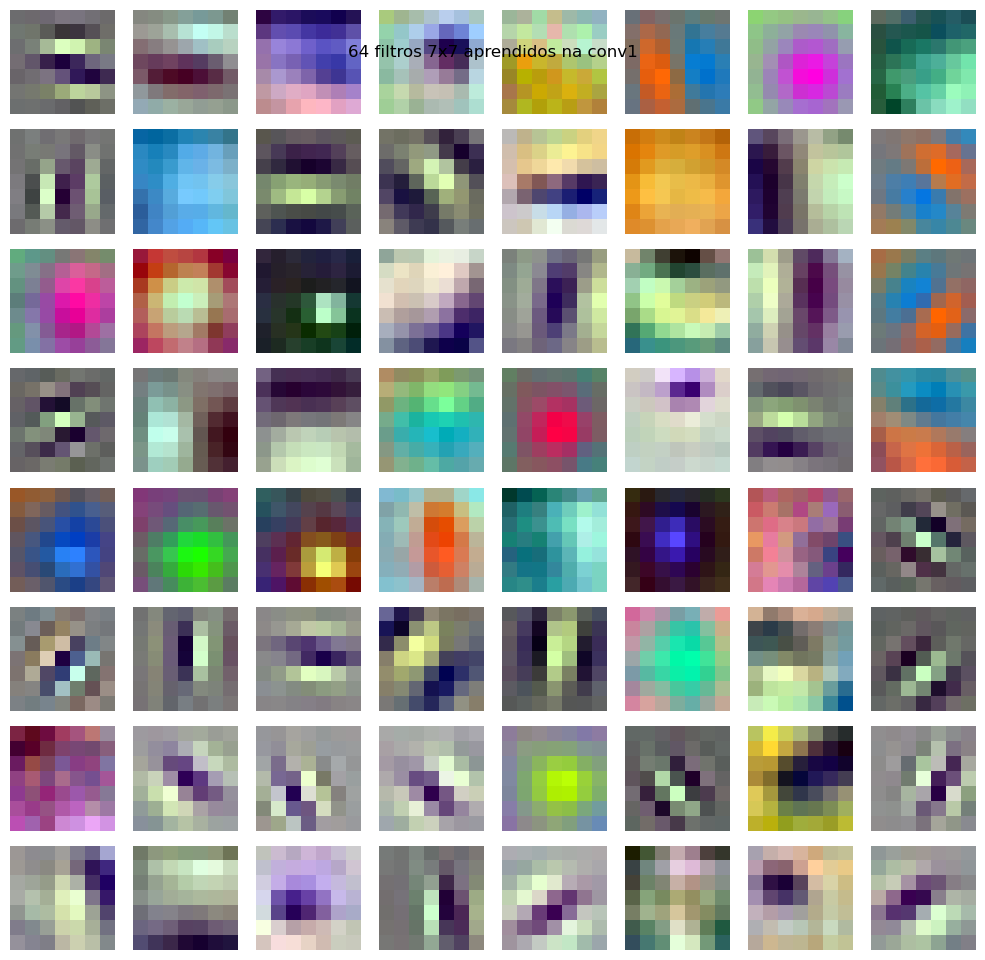

In [8]:
filtros = modelo.conv1.weight.detach().cpu().clone()   # [64, 3, 7, 7]
# Normaliza para [0,1]
fmin = filtros.amin(dim=(1,2,3), keepdim=True)
fmax = filtros.amax(dim=(1,2,3), keepdim=True)
filtros_n = (filtros - fmin) / (fmax - fmin + 1e-9)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(filtros_n[i].permute(1, 2, 0).numpy())
    ax.axis('off')
plt.suptitle('64 filtros 7x7 aprendidos na conv1', y=0.92)
plt.tight_layout(); plt.show()

## 7. Grad-CAM (implementação mínima)

**Grad-CAM** (Gradient-weighted Class Activation Mapping) responde a uma pergunta intuitiva: *"qual região da imagem fez a rede prever a classe X?"*. 

**Receita** (Selvaraju et al., 2017):
1. Faz forward até a última conv (`layer4`).
2. Pega o gradiente do **logit da classe alvo** em relação às feature maps dessa camada.
3. Faz `mean` desses gradientes em H,W → pesos por canal.
4. Combina linearmente os feature maps usando esses pesos.
5. Aplica ReLU (só pixels que contribuem positivamente).
6. Normaliza e redimensiona para o tamanho da imagem.

Usamos **dois hooks**: um forward para capturar a saída de `layer4`, um backward para capturar o gradiente.

In [9]:
# Precisamos do modelo em modo treino para gradientes (mas mantemos BN/Dropout em eval)
# Truque: model.eval() mantém-se, mas habilitamos gradientes explicitamente
modelo.eval()
for p in modelo.parameters():
    p.requires_grad_(True)

# Armazenamento
feature_maps = {}
gradientes   = {}

def hook_fwd(modulo, entrada, saida):
    feature_maps['layer4'] = saida

def hook_bwd(modulo, grad_in, grad_out):
    # grad_out é uma tupla; pegamos o primeiro tensor
    gradientes['layer4'] = grad_out[0]

h_fwd = modelo.layer4.register_forward_hook(hook_fwd)
h_bwd = modelo.layer4.register_full_backward_hook(hook_bwd)

# Forward (sem no_grad — precisamos do grafo para backward)
img_input = img_tensor.clone().requires_grad_(True)
logits = modelo(img_input)
classe_alvo = logits.argmax(dim=1).item()
score = logits[0, classe_alvo]

# Backward só no score da classe alvo
modelo.zero_grad()
score.backward()

# Remove os hooks
h_fwd.remove(); h_bwd.remove()

print(f"Classe predita: {weights.meta['categories'][classe_alvo]} (idx={classe_alvo})")
print(f"Feature maps: {feature_maps['layer4'].shape}")
print(f"Gradientes:   {gradientes['layer4'].shape}")

Classe predita: Samoyed (idx=258)
Feature maps: torch.Size([1, 512, 7, 7])
Gradientes:   torch.Size([1, 512, 7, 7])


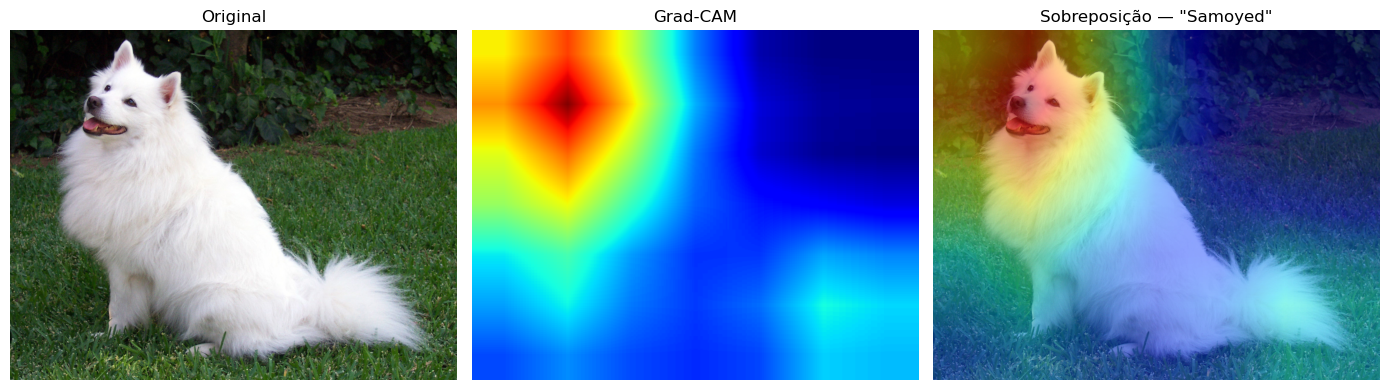

In [10]:
# Passo 3-4: combinar feature maps com pesos (média espacial dos gradientes)
fmaps = feature_maps['layer4'][0]      # [512, 7, 7]
grads = gradientes['layer4'][0]        # [512, 7, 7]

pesos = grads.mean(dim=(1, 2))         # [512] — um peso por canal
cam = (pesos.view(-1, 1, 1) * fmaps).sum(dim=0)  # [7, 7]

# Passo 5: ReLU
cam = F.relu(cam)

# Passo 6: normaliza para [0,1] e redimensiona para tamanho da imagem
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-9)
cam = cam.detach().cpu().numpy()

# Redimensiona para tamanho da imagem (usando PIL)
cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize(img_pil.size, Image.BILINEAR)
cam_np = np.array(cam_img) / 255.0

# Plot: original | heatmap | sobreposição
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_pil); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cam_np, cmap='jet'); axes[1].set_title('Grad-CAM'); axes[1].axis('off')
axes[2].imshow(img_pil)
axes[2].imshow(cam_np, cmap='jet', alpha=0.45)
axes[2].set_title(f'Sobreposição — "{weights.meta["categories"][classe_alvo]}"')
axes[2].axis('off')
plt.tight_layout(); plt.show()

## 8. Mixed precision (`torch.cuda.amp`)

**Mixed precision** treina parte do forward em `float16` (mais rápido + menos memória) e parte em `float32` (estabilidade). Em GPUs modernas (RTX, A100, H100) **acelera 2-3x** sem perda significativa de qualidade.

Componentes:
- `autocast()`: contexto que decide automaticamente onde usar fp16/fp32.
- `GradScaler()`: escala o loss para evitar underflow no backward em fp16.

Abaixo mostramos o **padrão de uso** num loop de treino. Se você não tem GPU CUDA, o código abaixo ainda funciona (cai pra fp32), mas o ganho de velocidade só aparece em GPU.

In [11]:
# Exemplo de loop de treino com mixed precision
# Note: este é um exemplo curto SOBRE A API — não treina nada de fato.

from torch.cuda.amp import autocast, GradScaler

tem_cuda = torch.cuda.is_available()
print(f"CUDA disponível: {tem_cuda} -> {'ganho real de velocidade' if tem_cuda else 'fallback fp32, sem speedup'}")

# Modelo dummy + dado dummy
dummy_model = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(16, 10)
).to(device)

X_dummy = torch.randn(8, 3, 32, 32, device=device)
y_dummy = torch.randint(0, 10, (8,), device=device)

optimizer = optim.Adam(dummy_model.parameters(), lr=1e-3)
criterio = nn.CrossEntropyLoss()
scaler = GradScaler(enabled=tem_cuda)

# Uma "iteração" com AMP
optimizer.zero_grad()
with autocast(enabled=tem_cuda):
    logits = dummy_model(X_dummy)
    loss = criterio(logits, y_dummy)

# Backward + step com scaler
scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()

print(f"Loss (uma iteração demo): {loss.item():.4f}")
print("\nPadrão completo num loop:")
print('''
scaler = GradScaler()
for X, y in train_loader:
    optimizer.zero_grad()
    with autocast():
        logits = model(X)
        loss = criterio(logits, y)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
''')

CUDA disponível: False -> fallback fp32, sem speedup


/var/folders/w9/djvfy0nd65579854g_tc3t3r0000gn/T/ipykernel_59364/2242498654.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=tem_cuda)
/var/folders/w9/djvfy0nd65579854g_tc3t3r0000gn/T/ipykernel_59364/2242498654.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=tem_cuda):


Loss (uma iteração demo): 2.2762

Padrão completo num loop:

scaler = GradScaler()
for X, y in train_loader:
    optimizer.zero_grad()
    with autocast():
        logits = model(X)
        loss = criterio(logits, y)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()



## 9. Persistência correta: `state_dict`

**Boa prática**: salvar **apenas** o `state_dict` (dicionário de pesos), não o objeto modelo inteiro. Isso desacopla o checkpoint da definição da classe.

Vamos demonstrar: salvar, recarregar e verificar **igualdade tensor a tensor** com `torch.equal`.

In [12]:
# Salva
CKPT = "resnet18_state.pth"
torch.save(modelo.state_dict(), CKPT)
print(f"Salvo em {CKPT} ({os.path.getsize(CKPT)/1e6:.2f} MB)")

# Carrega num modelo novo
modelo_recarregado = models.resnet18(weights=None).to(device)
modelo_recarregado.load_state_dict(torch.load(CKPT, map_location=device))
modelo_recarregado.eval()

# Verifica igualdade
sd1 = modelo.state_dict()
sd2 = modelo_recarregado.state_dict()

todas_iguais = True
for k in sd1.keys():
    if not torch.equal(sd1[k], sd2[k]):
        todas_iguais = False
        print(f"  DIFERENTE em {k}")

print(f"\nTodos os tensores são bit-a-bit iguais? {todas_iguais}")

# Limpa o arquivo
os.remove(CKPT)

Salvo em resnet18_state.pth (46.84 MB)



Todos os tensores são bit-a-bit iguais? True


### Por que NÃO salvar `torch.save(modelo, ...)` (o objeto inteiro)?

1. Acopla o checkpoint ao código exato da classe — se você renomear `bloco1` para `block1`, não carrega mais.
2. Vulnerável: `torch.load` executa `pickle`, que pode rodar código arbitrário.
3. Maior, menos portável entre versões.

Sempre prefira `state_dict`.

## 10. Export para TorchScript

**TorchScript** é a representação intermediária que permite **rodar o modelo sem o interpretador Python** — útil em produção, mobile, edge e C++.

Duas formas:
- `torch.jit.trace`: roda o modelo com um input de exemplo e **grava** as operações executadas. Bom para arquiteturas sem branches dinâmicos.
- `torch.jit.script`: analisa o **código Python** estaticamente. Suporta if/else dinâmico.

Aqui usamos `trace`, que é o mais comum para CNNs feed-forward.

In [13]:
modelo.eval()

# Input dummy do shape correto
dummy = torch.randn(1, 3, 224, 224, device=device)

# Tracing
modelo_traced = torch.jit.trace(modelo, dummy)
modelo_traced.save("resnet18_traced.pt")
print(f"Salvo TorchScript: {os.path.getsize('resnet18_traced.pt')/1e6:.2f} MB")

# Carrega de volta
modelo_jit = torch.jit.load("resnet18_traced.pt", map_location=device)
modelo_jit.eval()

# Compara as saídas: devem ser idênticas (até diferença numérica mínima)
with torch.no_grad():
    out_original = modelo(img_tensor)
    out_traced   = modelo_jit(img_tensor)

diff_max = (out_original - out_traced).abs().max().item()
print(f"Diferença máxima entre original e traced: {diff_max:.2e}")
print(f"Top-1 igual? {out_original.argmax() == out_traced.argmax()}")

os.remove("resnet18_traced.pt")

Salvo TorchScript: 46.96 MB


Diferença máxima entre original e traced: 0.00e+00
Top-1 igual? True


## 11. Reprodutibilidade total

Para conseguir **resultados idênticos** entre execuções, precisamos fixar a aleatoriedade em **quatro lugares**:

1. `random` (Python).
2. `numpy`.
3. `torch` (CPU **e** CUDA).
4. **cuDNN** (`deterministic=True`, `benchmark=False`).

Também precisamos fixar a seed do `Generator` usado no `random_split` / `DataLoader` se houver shuffle.

In [14]:
def set_seed(seed: int):
    """Fixa a aleatoriedade em todas as fontes."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # cuDNN: prioriza determinismo sobre velocidade
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Em PyTorch >= 1.8 (recomendado)
    os.environ["PYTHONHASHSEED"] = str(seed)

# Demonstração: duas execuções com mesma seed -> mesma saída
set_seed(123)
modelo_a = nn.Linear(10, 5)
x = torch.randn(2, 10)
y_a = modelo_a(x)

set_seed(123)
modelo_b = nn.Linear(10, 5)
x_b = torch.randn(2, 10)
y_b = modelo_b(x_b)

print(f"Entradas iguais?  {torch.equal(x, x_b)}")
print(f"Saídas iguais?    {torch.equal(y_a, y_b)}")
print(f"Pesos iguais?     {torch.equal(modelo_a.weight, modelo_b.weight)}")

Entradas iguais?  True
Saídas iguais?    True
Pesos iguais?     True


### Quando NÃO usar `deterministic=True`?

Em treinos de produção, geralmente vale mais a pena ter `benchmark=True` (cuDNN escolhe algoritmos rápidos) do que determinismo total. Reproduzibilidade absoluta só é crítica em **debugging** ou **publicação científica**.

## 12. Benchmark de `num_workers`

O parâmetro `num_workers` do `DataLoader` controla quantos processos paralelos carregam os dados. Valores comuns: 2, 4, 8. Mas o **ótimo depende** da máquina, do dataset e do tamanho do batch.

Vamos medir o tempo de iterar **um epoch** sobre o CIFAR-10 com `num_workers ∈ {0, 2, 4}`. Note que o resultado varia muito entre máquinas (CPU/HD/SSD).

In [15]:
# Dataset leve para o benchmark
transform_simples = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3),
])
cifar_bench = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_simples
)

def medir_tempo_epoca(num_workers, batch_size=128, n_iter=None):
    """Itera o DataLoader uma vez e mede o tempo."""
    loader = DataLoader(
        cifar_bench, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=False,
        persistent_workers=(num_workers > 0)
    )
    t0 = time.perf_counter()
    for i, (Xb, yb) in enumerate(loader):
        if n_iter is not None and i >= n_iter:
            break
    return time.perf_counter() - t0

# Usamos n_iter=50 para não esperar demais
N_ITER = 50
print(f"Medindo tempo para iterar {N_ITER} batches do CIFAR-10\n")
resultados = {}
for nw in [0, 2, 4]:
    # Warmup (descarta primeira execução, que tem overhead de criar workers)
    _ = medir_tempo_epoca(nw, n_iter=5)
    t = medir_tempo_epoca(nw, n_iter=N_ITER)
    resultados[nw] = t
    print(f"  num_workers={nw}: {t:.2f}s")

Medindo tempo para iterar 50 batches do CIFAR-10



  num_workers=0: 0.34s


  num_workers=2: 4.58s


  num_workers=4: 8.64s


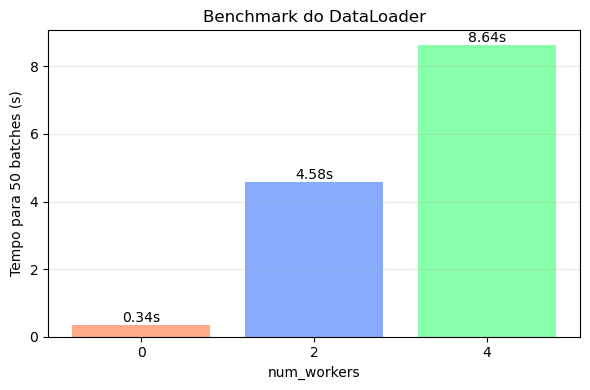


Melhor configuração nesta máquina: num_workers=0


In [16]:
# Plot dos resultados
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(k) for k in resultados.keys()], list(resultados.values()), color=['#FFAA88', '#88AAFF', '#88FFAA'])
ax.set_xlabel('num_workers'); ax.set_ylabel(f'Tempo para {N_ITER} batches (s)')
ax.set_title('Benchmark do DataLoader')
ax.grid(alpha=0.3, axis='y')
for i, (k, v) in enumerate(resultados.items()):
    ax.text(i, v, f'{v:.2f}s', ha='center', va='bottom')
plt.tight_layout(); plt.show()

# Mensagem prática
melhor = min(resultados, key=resultados.get)
print(f"\nMelhor configuração nesta máquina: num_workers={melhor}")

### Dicas práticas

- `num_workers=0` (default) roda no processo principal — útil para debug, mas geralmente lento.
- **No Windows e em notebooks**, valores altos podem dar problemas; teste 2 ou 4 primeiro.
- **Em servidores Linux**, comece com `num_workers = min(8, os.cpu_count())`.
- `pin_memory=True` ajuda quando vai para GPU (`tensor.to(device, non_blocking=True)`).
- `persistent_workers=True` evita recriar os workers a cada época.

## Resumo e checklist final

Você agora tem na mochila as ferramentas que separam um usuário casual de um engenheiro de ML maduro:

**Inspeção e debug**
- [x] Listar `state_dict().keys()` e contagem de parâmetros.
- [x] `register_forward_hook` para capturar ativações intermediárias.
- [x] Visualizar **pesos** vs **feature maps** (não são a mesma coisa).

**Explicabilidade**
- [x] **Grad-CAM** para entender onde a rede "olha".

**Performance**
- [x] **Mixed precision** com `autocast` + `GradScaler`.
- [x] Benchmark de `num_workers`.

**Produção**
- [x] Salvar **apenas** `state_dict`, não o objeto inteiro.
- [x] Export para **TorchScript** via `torch.jit.trace`.

**Reprodutibilidade**
- [x] `set_seed(seed)` em 4 lugares + cuDNN deterministic.

### Onde ir agora

- **Detecção e segmentação** (Faster R-CNN, Mask R-CNN, YOLO) — CNNs com cabeças especializadas. Vimos isso brevemente no notebook 1; é o caminho natural após classificação.
- **Arquiteturas modernas**: EfficientNet, ConvNeXt, Vision Transformers.
- **Distributed training**: `DistributedDataParallel` (DDP), gradient accumulation.
- **Quantização e poda**: para deploy em mobile/edge.